# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Eric Lopes, Guilherme Braga, Guilherme Saggion

**RA**: 822873, 823161, 823159


---
## Análise exploratória

Nesta seção, deve ser feita a leitura da base de dados e todas as análises necessárias para interpretar e analisar os dados, tais como:
* Significado de cada atributo
* Medidas descritivas
* Gráficos

### 1. Importação de bibliotecas e inicialização de parâmetros

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import analise_exploratoria as ae

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Bibliotecas importadas e configurações definidas com sucesso.")

Bibliotecas importadas e configurações definidas com sucesso.


### 2. Carregamento dos dados

In [5]:
train_df, test_df, sample_submission = ae.carregar_dados(
    '../dados/train.csv', '../dados/test.csv', '../dados/sample_submission.csv'
)
train_valid = ae.filtrar_categorias_validas(train_df)

Treinamento : (22680, 3)
Teste       : (2521, 2)
Submissão   : (15, 2)


### 3. Estrutura e tipos dos dados

| Atributo   | Tipo   | Descrição |
|------------|--------|-----------|
| `Id`       | int64  | Identificador único do documento |
| `Body`     | object | Texto extraído de uma página do documento (via OCR) |
| `Category` | int64  | Classe: 0=Acórdão, 1=ARE, 2=Despacho, 3=RE, 4=Sentença |

In [6]:
ae.exibir_estrutura(train_df, test_df)

=== Primeiras linhas — treino ===


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3



=== Informações gerais — treino ===
<class 'pandas.DataFrame'>
RangeIndex: 22680 entries, 0 to 22679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        22680 non-null  int64
 1   Body      22680 non-null  str  
 2   Category  22680 non-null  int64
dtypes: int64(2), str(1)
memory usage: 531.7 KB

=== Primeiras linhas — teste ===


,Id,Body
0,9213,"{""um regime democrática direito qual seja da s..."
1,17427,"{""controvérsia fato que requerente participant..."
2,4753,"{""advocacia geral união procuradoria união par..."
3,4640,"{""advocacia geral união procuradoria união est..."
4,20412,"{""ministério fazenda procuradoria geral fazend..."


##### 1. Estrutura dos Dados
* Id: Identificador numérico único.

* Body: Texto bruto do documento jurídico.

* Category: Variável alvo numérica (classes 1 e 3 observadas na amostra).

##### 2. Anomalias Identificadas (Body)
* Erro de Codificação (Encoding): Caracteres acentuados distorcidos (ex: conclusÃ£o, uniÃ£o). 

* Ruídos de Formatação: Presença do prefixo {" nas strings. Indica resquícios de estrutura JSON ou dicionário.

* Características Textuais: Conteúdo predominantemente em letras minúsculas e sem pontuação regular, assemelhando-se a uma estrutura bag of words.

##### 3. Insights para o Pré-processamento
* Ajustar o encoding na leitura do CSV.

* Desenvolver função para remoção de artefatos como {" e limpeza de caracteres especiais.

* Aplicar o pipeline de PLN obrigatório: remoção de stop words, tokenização e lematização.

### 4. Qualidade dos dados (ausentes e duplicatas)

In [7]:
ae.verificar_qualidade(train_df, test_df)

=== Valores ausentes — treino ===
Id          0
Body        0
Category    0
dtype: int64

=== Valores ausentes — teste ===
Id      0
Body    0
dtype: int64

Body duplicado no treino : 11183
Body duplicado no teste  : 566

=== Categorias no treino ===
Category
-1     2268
 0      665
 1     3529
 2      439
 3    12876
 4     2903
Name: count, dtype: int64


#### Integridade, Duplicatas e Distribuição

##### 1. Qualidade dos Dados (Valores Ausentes)

- Não há valores ausentes (NaN) nas colunas de treino ou teste. Os dados estão estruturalmente completos.

##### 2. Anomalias Identificadas (Duplicatas e Classes)

- Volume Crítico de Duplicatas: Há um número alarmante de textos repetidos no Body. No treino, 11.183 textos são duplicados (praticamente 50% da base). No teste, são 566 textos repetidos. Em contextos jurídicos, isso geralmente indica documentos padronizados ("boilerplate") ou despachos em massa.

- A classe -1 possui 2.268 registros no treino. No entanto, o escopo do projeto prevê apenas cinco classes oficiais (0 a 4). Essa categoria representa ruído ou documentos não rotulados.

- Desbalanceamento Severo: A classe 3 (Recurso Extraordinário) é amplamente majoritária (12.876 amostras), enquanto as classes 2 (Despacho) e 0 (Acórdão) possuem menos de 700 amostras cada.

##### 3. Insights para o Pré-processamento

1. Tratamento da Categoria -1: Excluir os registros com a classe -1 do conjunto de treinamento, pois eles não são alvo da classificação do projeto e prejudicarão o aprendizado do modelo.

2. Gestão de Duplicatas: Avaliar a remoção das duplicatas exatas apenas no conjunto de treinamento:
   ```python
   train.drop_duplicates(subset=['Body'])
   ```
   Manter cópias idênticas no treino pode causar superajuste (*overfitting*).

3. Balanceamento: Devido à discrepância entre as classes, será obrigatório o uso de técnicas para minimizar ou acabar com o desbalanceamento durante o treinamento (ex: class_weight='balanced') e avaliar os modelos focando na métrica F1-Score.

### 5. Distribuição das classes


=== Distribuição das classes ===


,Contagem,Percentual (%)
Category_name,,
Desconhecido,2268,10.00
Acórdão,665,2.93
ARE,3529,15.56
Despacho,439,1.94
RE,12876,56.77
Sentença,2903,12.80


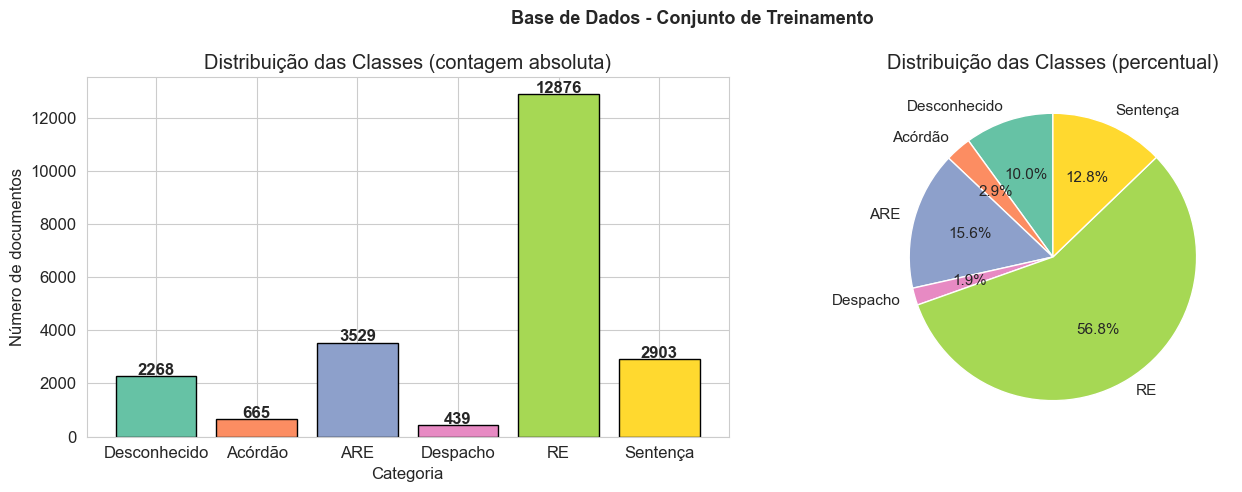


Total de amostras válidas: 22,680
Razão desbalanceamento (maior/menor): 29.33x


In [8]:
class_counts, class_pct = ae.plotar_distribuicao_classes(train_valid)

##### 1. Distribuição de Classes

- Desbalanceamento Extremo: O gráfico confirma visualmente o severo desbalanceamento de classes que foi notado na análise dos dados textuais. A categoria 3 (Recurso Extraordinário) domina massivamente o conjunto de dados, com um volume de amostras muito superior a todas as outras categorias combinadas.

- Classes Minoritárias: As categorias 0 (Acórdão) e 2 (Despacho) são as classes minoritárias, apresentando uma contagem de amostras significativamente baixa.

##### 2. Insights para o Pré-processamento

2. Estratégias de Balanceamento: A predominância da classe 3 e a escassez das classes 0 e 2 tornam o emprego de técnicas de balanceamento uma etapa crítica. Sem esse tratamento, o modelo tenderá a prever a classe 3 majoritariamente, ignorando as classes com menor representatividade. Serão consideradas as seguintes técnicas:

   - Ajuste de Pesos: Penalizar erros nas classes minoritárias durante o treinamento.
   - Sobreamostragem: Aumentar sinteticamente o número de amostras das classes minoritárias (ex: SMOTE).
   - Subamostragem: Reduzir o número de amostras da classe majoritária — menos recomendado se a base for pequena, mas viável dada a quantidade da classe 3.

3. Avaliação: Devido ao desbalanceamento, a acurácia não será uma métrica confiável. O projeto exige foco em métricas robustas ao desbalanceamento. O F1-Score será fundamental para avaliar se o modelo está realmente aprendendo a classificar as classes minoritárias.

### 6. Comprimento dos textos

=== Estatísticas de comprimento dos textos ===


,num_chars,num_words,num_sentences
count,22680.0,22680.0,22680.0
mean,1758.2,216.4,0.0
std,750.1,93.1,0.0
min,4.0,1.0,0.0
25%,1293.0,159.0,0.0
50%,1715.0,209.0,0.0
75%,2177.0,268.0,0.0
max,6867.0,844.0,0.0


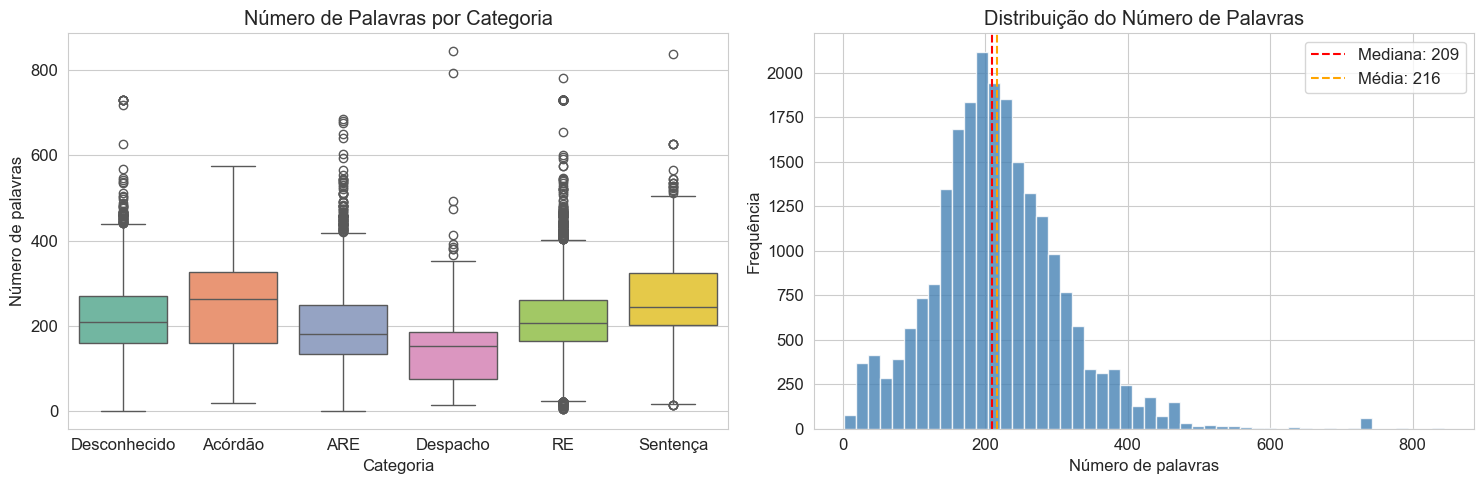


=== Média de palavras por categoria ===


,num_chars,num_words,num_sentences
Category_name,,,
Desconhecido,1769.6,218.0,0.0
Acórdão,2011.9,251.5,0.0
ARE,1578.1,195.2,0.0
Despacho,1195.7,149.0,0.0
RE,1746.6,213.9,0.0
Sentença,2047.0,254.4,0.0


In [11]:
train_valid = ae.adicionar_metricas_comprimento(train_valid)
ae.plotar_comprimento_textos(train_valid)

#### Análise Exploratória: Estatísticas de Comprimento dos Textos

##### 1. Visão Geral da Distribuição

- Variação de Tamanho: Os documentos possuem, em média, 216 palavras (cerca de 1.757 caracteres). No entanto, o desvio padrão de 92,8 palavras indica uma dispersão considerável.

- Valores Atípicos (Outliers): O valor mínimo aponta para textos com apenas 1 palavra (4 caracteres), o que provavelmente representa ruído de extração (OCR) ou falhas de formatação. O valor máximo atinge 844 palavras.

##### 2. Anomalias Identificadas

- Ausência de Sentenças: A métrica num_sentences está em 0.0 para todas as faixas e categorias. Isso comprova de forma definitiva a observação anterior de que o texto não possui pontuação regular (pontos finais, exclamações, etc.), comportando-se como uma bag of words.

##### 3. Diferenças por Categoria

- Padrões de Extensão: O tamanho do texto varia de acordo com o tipo de documento. "Sentença" (média de 254 palavras) e "Acórdão" (251 palavras) são os documentos mais extensos.

- Textos Curtos: A categoria "Despacho" é significativamente mais curta, com média de apenas 149 palavras, o que faz sentido do ponto de vista jurídico (costumam ser decisões rápidas de andamento processual).

##### 4. Recomendações para Modelagem

1. Filtro de Ruído: Deve ser avaliado a exclusão de registros excessivamente curtos, pois não contêm contexto jurídico suficiente para classificação.

2. Engenharia de Atributos: O número de palavras (num_words) pode ser adicionado como uma nova variável numérica para ajudar modelos (como Random Forest ou XGBoost) a diferenciar um Despacho de uma Sentença.

3. Limites para Deep Learning: Como 75% dos textos têm até 268 palavras, é importante considerar que tokenizadores de modelos como o BERT tipicamente geram entre 1,2x e 1,5x mais tokens do que palavras - ou seja, 268 palavras podem corresponder a aproximadamente 320-400 tokens. Por isso, ao utilizar Transformers, recomenda-se max_length=512 tokens para garantir que a maior parte do contexto seja preservada sem truncamentos indevidos, evitando perda de informação nas classes minoritárias.

### 7. Frequência de termos 

Vocabulário (sem stopwords): 34,854 termos únicos
Total de tokens            : 3,960,848


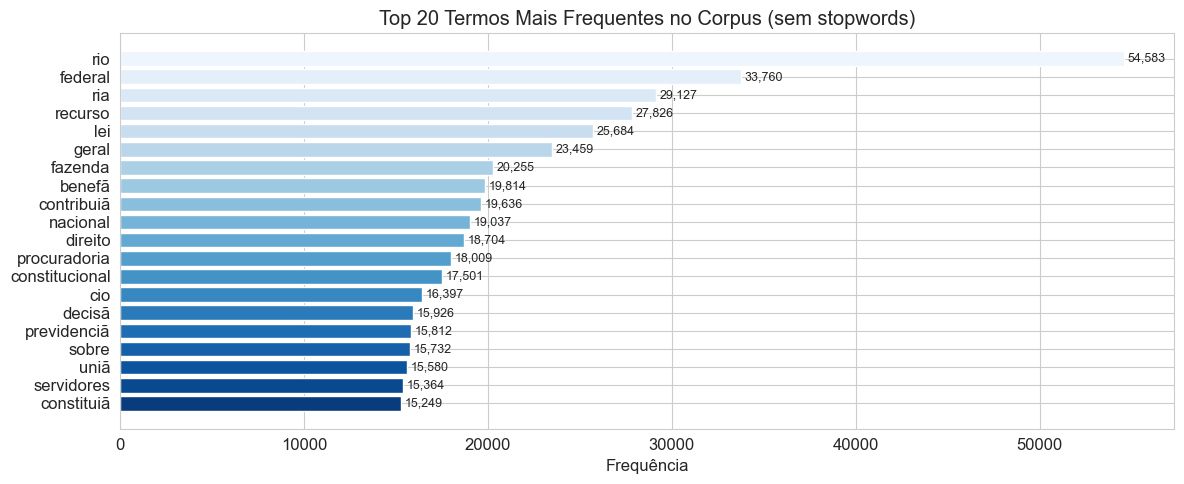

In [10]:
freq_global = ae.calcular_frequencia_global(train_valid)
ae.plotar_top_termos_global(freq_global)

* Análise: O que se torna visível é a confirmação da presença de erros nas palavras decorrentes da falta de tratamento e pré-processamento, algo que já foi levantado anteriormente.

### 8. Frequência de termos (por categoria)

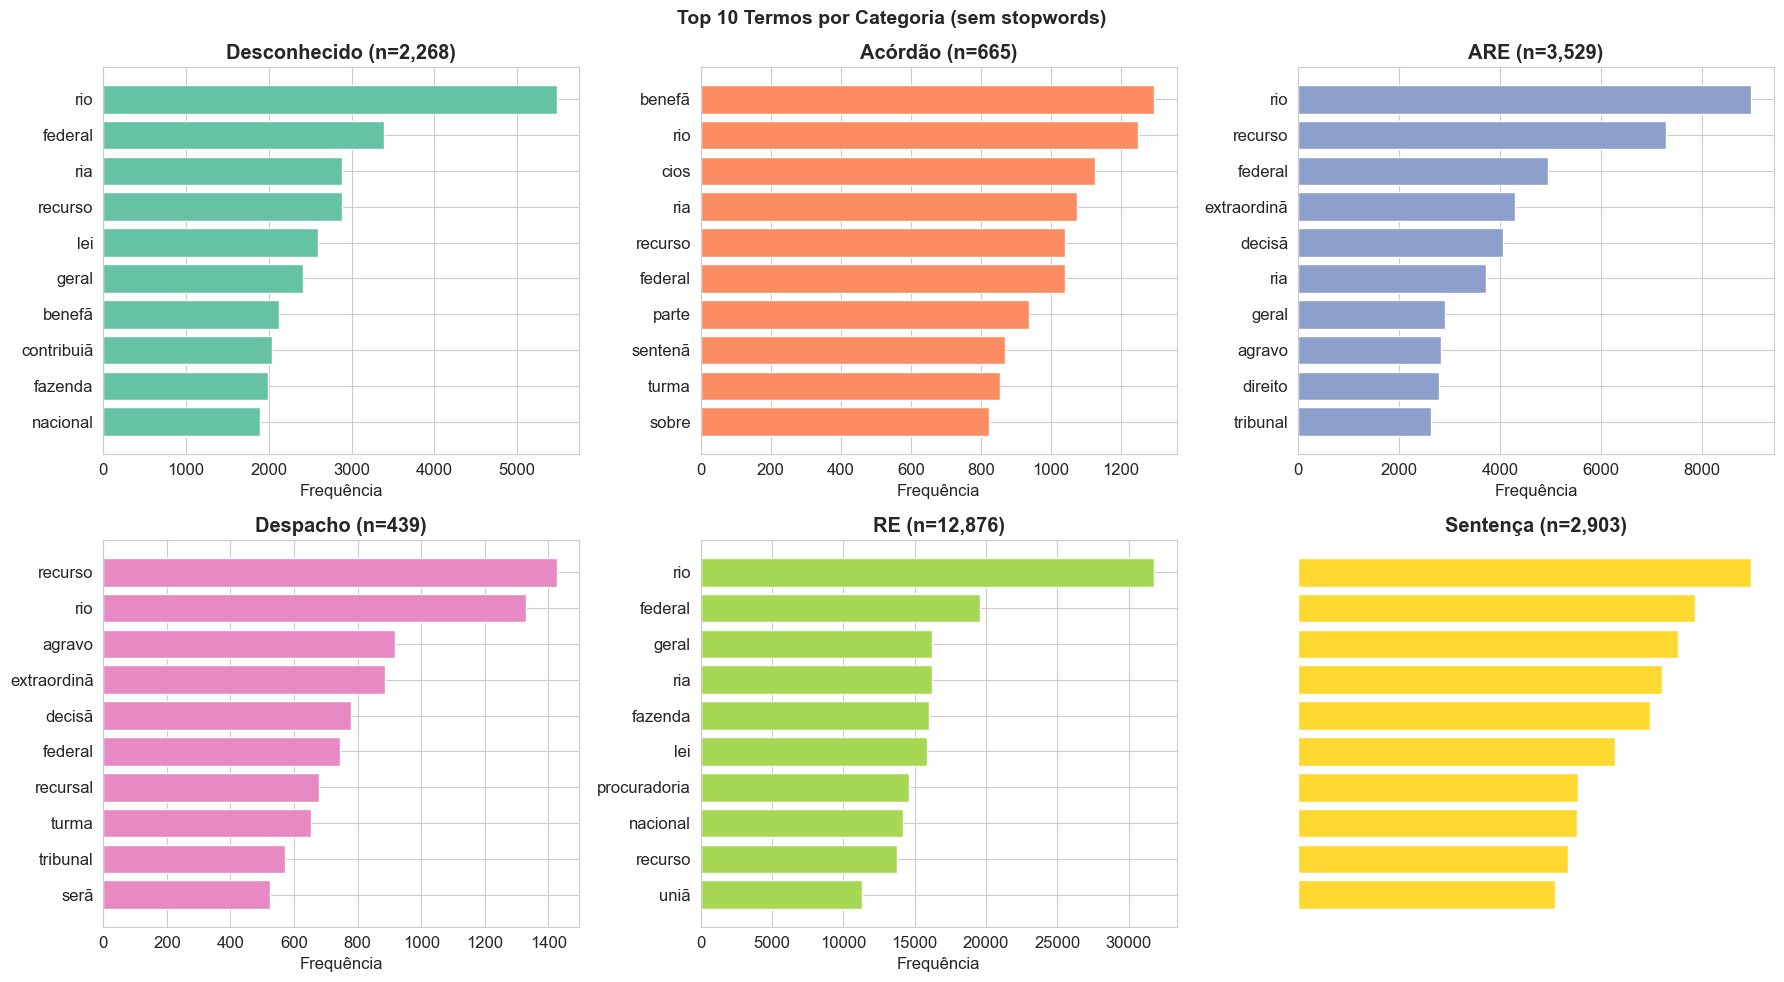

In [12]:
ae.plotar_top_termos_por_categoria(train_valid)

* Ainda se mostra evidente a presença de palavras errôneas com os erros de extração (sem correção).
Após a correção na etapa de Pré-processamento esses dados serão novamente mostrados para que seja confirmado a correção e o tratamento dos dados presentes.


1. Conexão Geral
* Existem palavras que aparecem no topo de quase todas as categorias, o que indica a natureza comum do dataset

* "rio": É o termo mais frequente em RE, ARE e Sentença, e o segundo em Acórdão e Despacho. Isso correlaciona fortemente todos os documentos a uma jurisdição específica (provavelmente Rio de Janeiro) ou a tribunais regionais.

* "federal": Presente em todos os gráficos. Reforça que a base de dados trata de matérias de competência da Justiça Federal ou instâncias superiores da União.

* "recurso": Onipresente, mas com peso maior em Despacho e ARE, onde a gestão do fluxo processual é o objetivo principal do documento.

2. Correlação por Cluster de Documentos
- Cluster de Admissibilidade e Rito (ARE, RE e Despacho)
- Estes documentos apresentam uma alta correlação terminológica voltada para o "caminho" do processo:

* Termos Chave: extraordinã (extraordinário), agravo, decisã (decisão).

* Análise: O ARE (Agravo em Recurso Extraordinário) e o Despacho compartilham quase os mesmos termos (agravo, extraordinário, decisão). Isso ocorre porque o Despacho, neste contexto, costuma ser o ato que decide sobre a subida ou não desses recursos.

* O "RE" (Recurso Extraordinário) se diferencia por trazer termos como fazenda, procuradoria e uniã, indicando que, no volume total, a maioria dos recursos extraordinários envolve entes públicos (União/Fazenda Nacional).

- Cluster de Decisão e Mérito (Sentença e Acórdão)
- Aqui a correlação muda do "procedimento" para o "direito discutido":

* Termos Chave: benefã (benefício), contribuí (contribuinte), lei, previdenciã (previdenciária).

* Análise: Existe uma correlação temática forte entre Sentença e Acórdão em torno de direitos sociais e tributários. O termo "benefã" (benefício) lidera os Acórdãos e está no topo das Sentenças, sugerindo que o grosso das decisões finais versa sobre benefícios (provavelmente previdenciários, dado o termo previdenciã na Sentença).

* Diferença: A Sentença foca mais no indivíduo/detalhe (contribuinte, servidores), enquanto o Acórdão mantém termos de colegiado (turma, cios - provavelmente de 'vencidos' ou 'unânimes').

3. Matriz de Especialidade
- RE (n=12.876): Correlaciona-se com a Administração Pública (fazenda, união, nacional).

- Sentença (n=2.903): Correlaciona-se com o Direito Previdenciário/Tributário (lei, contribuição, servidores).

- ARE e Despacho: Correlacionam-se com a Dinâmica de Instâncias Superiores (agravo, extraordinário).

- Conclusão da Análise
* A correlação sugere que o conjunto de dados é majoritariamente composto por contencioso de massa contra a União ou Autarquias Federais, concentrado no Rio de Janeiro. Enquanto os documentos de "meio" (ARE e Despacho) são puramente procedimentais, os documentos de "ponta" (Sentença e Acórdão) revelam que o tema central da disputa é o pagamento de benefícios e tributos.

### 9. Exemplos de texto por categoria

In [13]:
ae.exibir_exemplos_por_categoria(train_valid)

=== Exemplos de textos por categoria ===

--- Desconhecido (Categoria -1) ---
{"ARTIGO_16 serÃ¡ concedida nos termos regulamento indenizaÃ§Ã£o cr quatro mil duzentos cruzeiros por dia aos servidores que afastarem seu local trabalho sem direito percepÃ§Ã£o diÃ¡ria para execuÃ§Ã£o trabalhos campo tais como de campanhas combate controle endÃªmias marcaÃ§Ã£o inspeÃ§Ã£o manutenÃ§Ã£o marcos decisÃ³rios topografia pesquisa saneamento bÃ¡sico inspeÃ§Ã£o fiscalizaÃ§Ã£o fronteiras in
...

--- Acórdão (Categoria 0) ---
{"vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andrÃ© carvalho mendonÃ§a juiz federal relator"}
...

--- ARE (Categoria 1) ---
{"seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedimento possa ser considerado longo prazo razÃ£o disso passÃ­vel gerar acesso 

##### 1. Acórdão (Categoria 0)
Foco: Decisão Colegiada.

Análise: O texto é uma ementa ou dispositivo final. Utiliza fórmulas padrão de julgamento em grupo, como "unanimidade" e "negar provimento". É o documento que encerra uma fase processual em tribunais (neste caso, uma Turma Recursal em Pernambuco).

##### 2. ARE - Agravo em Recurso Extraordinário (Categoria 1)
Foco: Impugnação de bloqueio de recurso.

Análise: O texto ataca o "desacerto" de uma decisão anterior que impediu a subida de um Recurso Extraordinário. O conteúdo é focado em Assistência Social (Art. 203 da Constituição), discutindo critérios de deficiência e amparo assistencial (LOAS).

##### 3. Despacho (Categoria 2)
Foco: Admissibilidade e movimentação.

Análise: Funciona como um "filtro". O magistrado analisa se o recurso interposto (no caso, pela empresa GVT) atende aos requisitos do Art. 102 da Constituição. É um texto formal e administrativo que prepara o processo para o próximo passo.

##### 4. RE - Recurso Extraordinário (Categoria 3)
Foco: Argumentação da Parte (Petição).

Análise: Diferente dos anteriores, este fragmento tem um tom de súplica e convencimento ("espera e confia", "violação flagrante"). É a peça onde o advogado pede a reforma ou anulação de uma decisão, geralmente citando o Rio de Janeiro como sede.

##### 5. Sentença (Categoria 4)
Foco: Fundamentação de Mérito e Lei.

Análise: Este trecho é denso em doutrina e legislação. Discute prazos de decadência e a aplicação da Lei 9.784 em benefícios previdenciários. Enquanto o RE argumenta e o Despacho encaminha, a Sentença analisa o direito aplicado ao caso concreto.

### 10. Ruído textual (artefatos de OCR)

=== Métricas de ruído textual por categoria ===


,prop_especiais,prop_digitos,prop_maiusculas
Category_name,,,
Desconhecido,0.0293,0.0061,0.0466
Acórdão,0.0298,0.0064,0.0457
ARE,0.0273,0.0049,0.0409
Despacho,0.0287,0.0062,0.0439
RE,0.0292,0.0061,0.0476
Sentença,0.0313,0.0076,0.0527


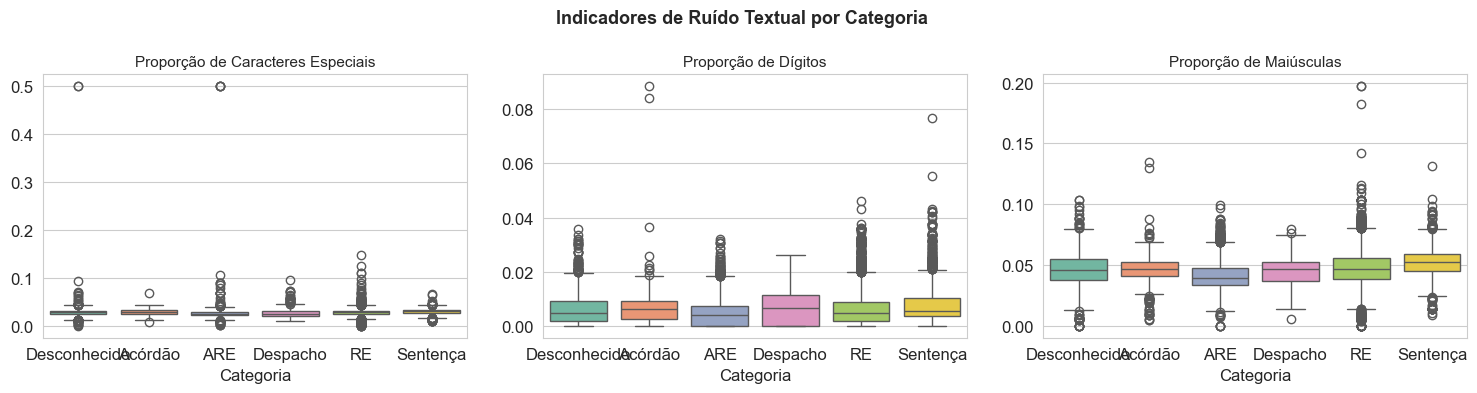

In [14]:
train_valid = ae.adicionar_metricas_ruido(train_valid)
ae.plotar_ruido_textual(train_valid)

1- Sentença é o "mais sujo": Lidera em caracteres especiais, números e letras maiúsculas por ser o documento de mérito mais detalhado.

2- ARE é o "mais limpo": Menor incidência de ruído, indicando um texto mais objetivo e menos técnico.

3- Anomalias (Outliers): Existem casos isolados no ARE com excesso de caracteres especiais (provável erro de OCR/conversão) e no Acórdão com muitos dígitos (prováveis tabelas de cálculos).

**Conclusão**: Para modelos de IA, as Sentenças exigem muito mais pré-processamento (limpeza) do que os AREs.

### 11. Resumo

In [15]:
ae.exibir_resumo(train_valid, test_df, freq_global, class_counts, class_pct)

         RESUMO DA ANÁLISE EXPLORATÓRIA
Amostras de treinamento (válidas) : 22,680
Amostras de teste                 : 2,521
Número de classes                 : 6
Tamanho do vocabulário            : 34,854 termos únicos
Média de palavras por documento   : 216
Mediana de palavras por documento : 209

Classes mais e menos representadas:
  Maior : RE (12,876 amostras, 56.8%)
  Menor : Despacho (439 amostras, 1.9%)

Observações para o pré-processamento:
  - Dataset desbalanceado: RE domina com ~56% dos dados.
  - Textos via OCR apresentam ruído (caracteres especiais).
  - Carimbos e assinaturas adicionam tokens irrelevantes.
  - Alto percentual de maiúsculas em cabeçalhos.
  - Limpeza e normalização são etapas críticas.


---
## Pré-processamento

Nesta seção, as funções da etapa de pré-processamento dos dados devem ser implementadas e aplicadas (se necessário).

In [1]:
%pip install --quiet pandas numpy matplotlib seaborn nltk

import nltk
nltk.download('stopwords', quiet=True)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\erics\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


True

### 1. Importação do módulo de pré-processamento

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import analise_exploratoria as ae
from scripts import preprocessamento as pp

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

train_df, test_df, sample_submission = ae.carregar_dados(
    '../dados/train.csv', '../dados/test.csv', '../dados/sample_submission.csv'
)
train_valid = ae.filtrar_categorias_validas(train_df)

print(f'Treino (válido) : {len(train_valid):,} amostras')
print(f'Teste           : {len(test_df):,} amostras')

Treinamento : (22680, 3)
Teste       : (2521, 2)
Submissão   : (15, 2)
Treino (válido) : 22,680 amostras
Teste           : 2,521 amostras


### 2. Estratégia de limpeza

São adotados dois níveis de limpeza, com base em Martins (2024) e Araujo et al. (2020):

| Nível | O que faz | Usado em |
|-------|-----------|----------|
| **Limpeza básica** | Extração do wrapper JSON · Correção de encoding (mojibake) · Unicode NFC · Minúsculas · Remove URLs, e-mails e referências de folhas (`fl.`, `fls.`, `pg.`) | Word2Vec · FastText · BERT · BiLSTM · todos os modelos neurais |
| **Limpeza completa** | Básica + Remove ruído OCR + Remove números isolados + Remove stopwords (NLTK pt) | TF-IDF + SVM · TF-IDF + Regressão Logística |

> **Justificativa:** Modelos neurais aprendem contexto sequencial — remover stopwords eliminaria relações importantes (ex.: 'não provimento'). Já o TF-IDF representa o texto como uma sacola de palavras, onde stopwords apenas geram ruído sem agregar valor discriminativo.

### 3. Demonstração em um documento

Antes de processar o corpus inteiro, visualizamos o efeito de cada nível em um único exemplo.

In [27]:
# Seleciona um documento de exemplo (primeiro Acordao do treino)
exemplo = train_valid[train_valid['Category'] == 0]['Body'].iloc[0]

pp.mostrar_exemplo(exemplo, n_chars=300)

──────────────────────────────────────────────────────────────
EFEITO DO PRE-PROCESSAMENTO (exemplo)
──────────────────────────────────────────────────────────────

ORIGINAL  (29 tokens):
  {"vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andrÃ© carvalho mendonÃ§a juiz federal relator"}...

LIMPEZA BASICA  (29 tokens):
  vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andré carvalho mendonça juiz federal relator...

LIMPEZA COMPLETA  (27 tokens):
  vistos etc decide segunda turma recursal juizados especiais federais pernambuco unanimidade negar provimento recurso termos voto acima recife data julgamento jorge andré carvalho mendonça juiz federal relator...
──────────────────────────────────────────────────────────────


### 4. Aplicação da limpeza básica

Aplicada ao conjunto de treino e de teste.

In [28]:
train_basico = pp.preprocessar(train_valid, nivel='basica')
test_basico  = pp.preprocessar(test_df,     nivel='basica')

print('Exemplo (treino):')
print(' ', train_basico['Body_basica'].iloc[0][:300])

──────────────────────────────────────────────────
 Limpeza basica — 22,680 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_basica
  Tokens (media) : 216 → 216  (reducao de 0.1%)

──────────────────────────────────────────────────
 Limpeza basica — 2,521 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_basica
  Tokens (media) : 218 → 218  (reducao de 0.0%)

Exemplo (treino):
  conclusão diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_102 iii constituição federal será admitido conhecido provido fim que seja anulado v acórdão impugnado assim não entender que seja inteiramente reformado por violação flagrante aos dispositivos co


### 5. Aplicação da limpeza completa

Aplicada ao conjunto de treino e de teste.

In [29]:
train_completo = pp.preprocessar(train_valid, nivel='completa')
test_completo  = pp.preprocessar(test_df,     nivel='completa')

# Verificação
print('Exemplo (treino):')
print(' ', train_completo['Body_completa'].iloc[0][:300])

──────────────────────────────────────────────────
 Limpeza completa — 22,680 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_completa
  Tokens (media) : 216 → 175  (reducao de 19.0%)

──────────────────────────────────────────────────
 Limpeza completa — 2,521 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_completa
  Tokens (media) : 218 → 177  (reducao de 18.9%)

Exemplo (treino):
  conclusão diante exposto recorrente espera confia recurso ora arrazoado interposto fulcro artigo_1 iii constituição federal admitido conhecido provido fim anulado acórdão impugnado assim entender inteiramente reformado violação flagrante dispositivos constitucionais suscitados razões recursais esper


### 6. Consolidação dos resultados

Montamos um DataFrame único com os três estágios (original, básico e completo) para facilitar as comparações a seguir.

In [31]:
import pandas as pd

df_comp = train_valid[['Id', 'Category', 'Body']].copy()
df_comp['Body_basica']    = train_basico['Body_basica']
df_comp['Body_completa']  = train_completo['Body_completa']

print('Colunas disponíveis:', df_comp.columns.tolist())
df_comp.head(5)

Colunas disponíveis: ['Id', 'Category', 'Body', 'Body_basica', 'Body_completa']


,Id,Category,Body,Body_basica,Body_completa
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera ...",conclusão diante exposto recorrente espera con...,conclusão diante exposto recorrente espera con...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",artigo_55 gecen a gacen serão devidas aos titu...,artigo_5 gecen gacen devidas titulares emprego...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimen...",seguir desacerto decisão que negou seguimento ...,seguir desacerto decisão negou seguimento recu...
3,22984,3,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",advocacia geral união procuradoria união paraí...,advocacia geral união procuradoria união paraí...
4,5716,3,"{""ministÃ©rio fazenda procuradoria geral fazen...",ministério fazenda procuradoria geral fazenda ...,ministério fazenda procuradoria geral fazenda ...


### 7. Comparação: distribuição de tokens por nível

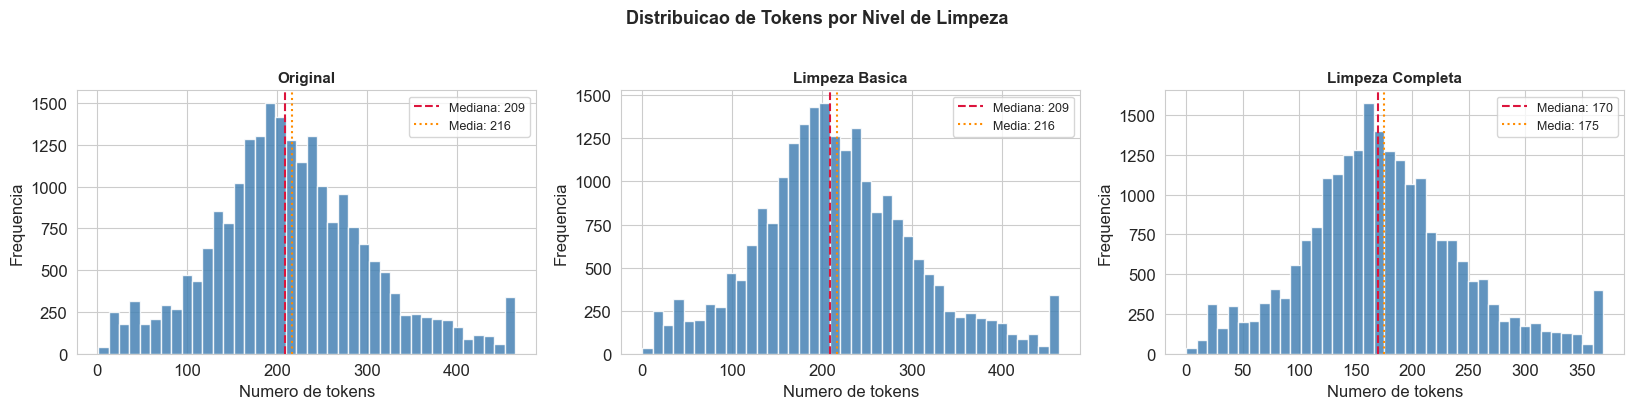

In [32]:
pp.plotar_tokens(df_comp)

### 8. Tabela comparativa

In [33]:
tabela = pp.tabela_comparativa(df_comp)
display(tabela)

,Media tokens,Mediana tokens,Vocabulario,Red. tokens (%),Red. vocab. (%)
Nivel,,,,,
Original,216.4,209.0,45486,0.0,0.0
Limpeza Basica,216.3,209.0,41208,0.1,9.4
Limpeza Completa,175.3,170.0,39594,19.0,13.0


### 9. Redução do vocabulário

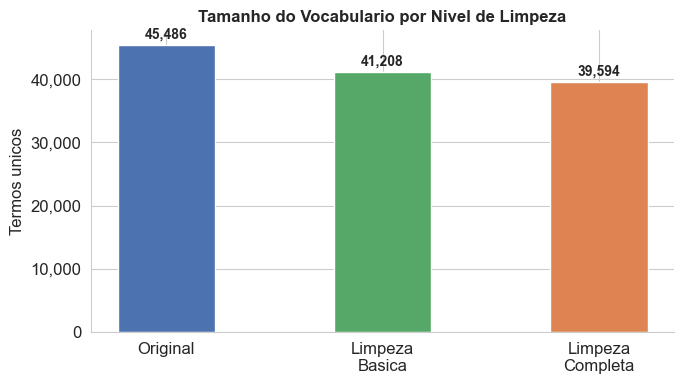

In [34]:
pp.plotar_vocabulario(df_comp)

### 10. Palavras mais frequentes — limpeza completa

Após remover stopwords, os termos restantes devem ser mais informativos e discriminativos entre as classes.

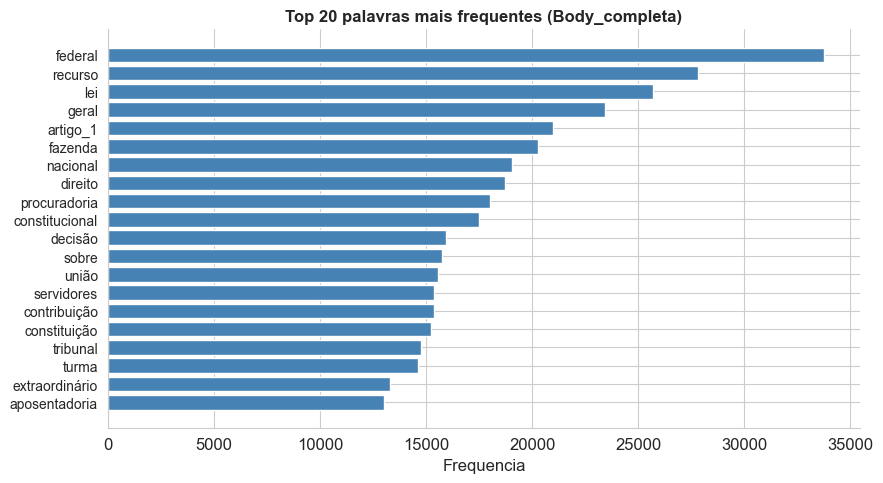

In [35]:
pp.plotar_top_palavras(df_comp, coluna='Body_completa', top_n=20)

### 11. Palavras mais frequentes por classe

Esta análise revela os termos mais característicos de cada tipo de documento, fornecendo intuição sobre quais features serão úteis para os classificadores.

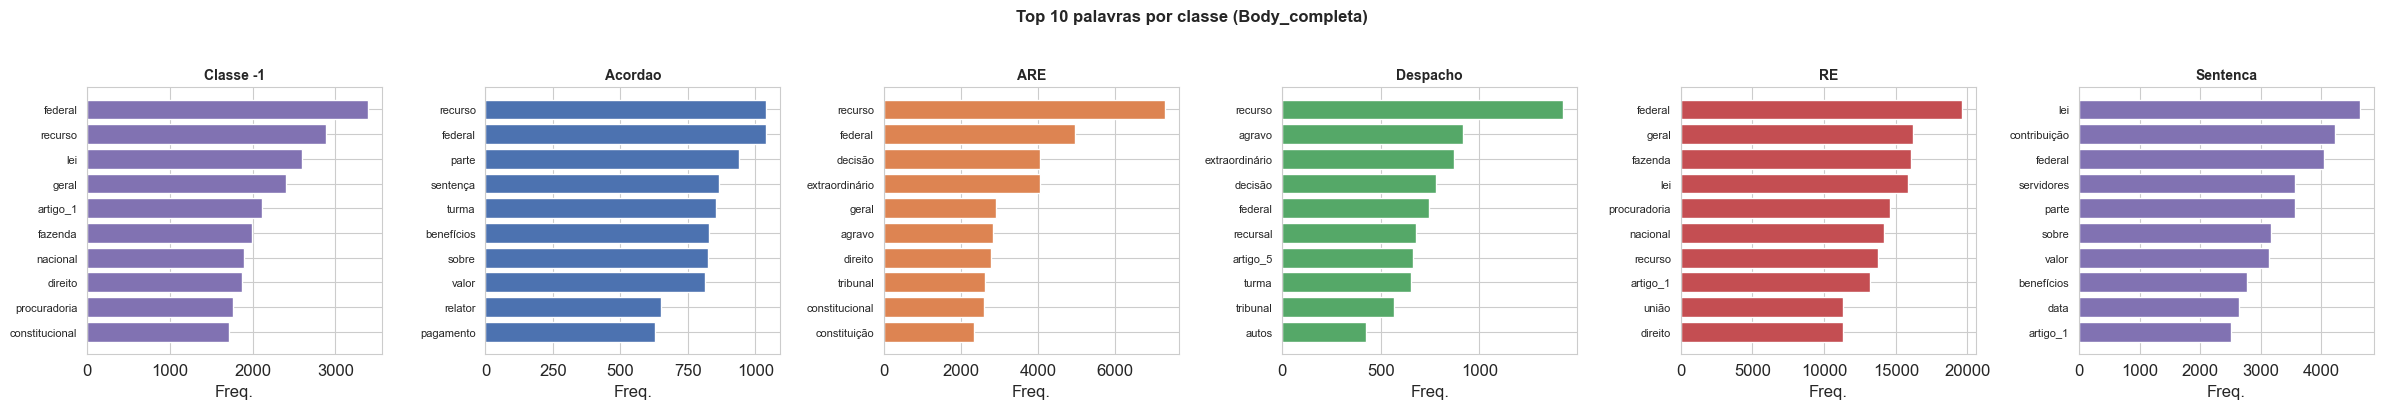

In [36]:
pp.plotar_top_palavras_por_classe(df_comp,
                                  coluna='Body_completa',
                                  top_n=10)

### 12. Resumo e conclusões do pré-processamento

In [37]:
pp.exibir_resumo(train_valid, df_comp)


  RESUMO DO PRE-PROCESSAMENTO
  Documentos processados : 22,680

  [Basica]
    Tokens medios  : 216 → 216  (↓ 0.1%)
    Vocabulario    : 41,208 termos unicos

  [Completa]
    Tokens medios  : 216 → 175  (↓ 19.0%)
    Vocabulario    : 39,594 termos unicos




### 13. Salvamento dos dados processados

In [38]:
# Treino
train_basico[['Id','Category','Body_basica']].to_csv(
    '../dados/train_basico.csv', index=False
)
train_completo[['Id','Category','Body_completa']].to_csv(
    '../dados/train_completo.csv', index=False
)

# Teste
test_basico[['Id','Body_basica']].to_csv(
    '../dados/test_basico.csv', index=False
)
test_completo[['Id','Body_completa']].to_csv(
    '../dados/test_completo.csv', index=False
)

print('Arquivos salvos com sucesso.')

Arquivos salvos com sucesso.


---
### Experimento

Nesta seção, o experimento deve ser conduzido, utilizando os protocolos experimentais padrões e testando diferentes modelos.

---
### Análise dos Resultados

Nesta seção, os resultados devem ser exibidos através de tabelas e gráficos, comparados e profundamente analisados.